In [1]:
import os
import json
import numpy as np
import pandas as pd
from glob import glob
from collections import defaultdict
import matplotlib.pyplot as plt
from dtwalign import dtw
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [2]:
# SPLIT_FILE = "../../my_rps_dataset/splits_noval.json"
OBS_RATIOS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
data_dir_list = ["/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2"]
results_all = {'OpenEndDTW': {}, 'SoftDTW': {}} 

Utils

In [3]:
def load_landmarks(path):
    """Load npz containing landmarks."""
    data = pd.read_csv(path)
    return data

def accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float(np.mean(y_true == y_pred))

In [4]:
def pad_landmark_frames_to_match_video_frames(
    landmarks, mp_idx, real_idx, action_onset_frame
) -> np.ndarray:
    """Pad a landmarks array so its first axis aligns with real_idx.

    For each frame in `real_idx` missing from `mp_idx`, this function inserts a copy
    of the *next* available landmark row. If the missing frame lies after the last
    mp_idx, it copies the previous available row instead.

    Args:
        landmarks: np.ndarray of shape (M, L, 3) where M == len(mp_idx)
        mp_idx: sequence of M increasing frame indices where landmarks were detected
        real_idx: sequence of N increasing frame indices representing real video frames

    Returns:
        np.ndarray of shape (N, L, 3) where rows corresponding to frames not in
        mp_idx are filled by copying the next available landmark row (or previous
        if missing at the end).
    """
    mp_idx = np.asarray(mp_idx, dtype=int)
    real_idx = np.asarray(real_idx, dtype=int)

    if landmarks.shape[0] != len(mp_idx):
        raise ValueError("landmarks.shape[0] must equal len(mp_idx)")

    # If no missing frames, quick return
    missing = sorted(set(real_idx) - set(mp_idx))
    if not missing:
        pass

    # Build an output buffer initialized with NaNs
    N = len(real_idx)
    L = landmarks.shape[1]
    C = landmarks.shape[2]
    out = np.full((N, L, C), np.nan, dtype=landmarks.dtype)

    # Create a map from mp_idx value -> row index in landmarks
    mp_to_row = {int(v): i for i, v in enumerate(mp_idx)}

    # Check mp_idx position relative to action_onset frame
    
    
    # Iterate over real_idx and fill from landmarks
    for out_i, frame in enumerate(real_idx):
        #if frame < action_onset_frame:
            
        if frame in mp_to_row:
            out[out_i] = landmarks[mp_to_row[frame]]
        else:
            # missing frame: find the insert position in mp_idx (first mp_idx > frame)
            insert_pos = np.searchsorted(mp_idx, frame, side="left")
            if insert_pos < len(mp_idx):
                # copy the next available landmark row
                src_row = insert_pos
                out[out_i] = landmarks[src_row]
            else:
                # missing frame is after last mp_idx: copy the last available row
                out[out_i] = landmarks[-1]

    return out


def get_padded_landmarks(class_metadata_files, csv_file_name, cols_to_use) -> np.ndarray:
    all_class_landmarks = []
    vid_names = []
    for meta_file in class_metadata_files: 
        print(f"Processing {meta_file}...")
        with open(meta_file, "r") as f:
            data = json.load(f)
        start, onset, end, _ = get_cropped_video_indices(data)
        vid_name = meta_file.split('/')[-2]
        landmarks_df = get_video_csv(BASE_DIR, vid_name, csv_file_name)
        landmarks_df_cropped = landmarks_df[(landmarks_df["frame_idx"] >= start) & (landmarks_df["frame_idx"] <= end)]
        
        real_indices = np.arange(start, end + 1)
        mediapipe_indices = landmarks_df_cropped.groupby("frame_idx")['frame_idx'].apply(list).index.to_numpy()

        #print(f"Using columns: {cols_to_use}")
        landmarks = landmarks_df_cropped[cols_to_use].to_numpy().reshape(-1, 21, 3)
        #print(f"Landmarks shape: {landmarks.shape}")
        action_onset_frame = data['action_frame_idx']
        landmarks_padded = pad_landmark_frames_to_match_video_frames(landmarks, mediapipe_indices, real_indices, action_onset_frame)
        #print(f"Padded landmarks shape: {landmarks_padded.shape}")

        all_class_landmarks.append(landmarks_padded)
        vid_names.append(vid_name)
        
    # Stack all landmarks for this class
    all_class_landmarks = np.array(all_class_landmarks)  # (n_videos, n_frames, n_landmarks, 3)

    return all_class_landmarks, vid_names


In [5]:
import sys
sys.path.append("/Users/christina/code/RockPaperScissors_backup/modules")
from utils import get_video_metadata, get_cropped_video_indices, load_splits_cropped, ALIGN_DIR
from get_frames import get_video_csv, get_frame_landmarks

BASE_DIR = "/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2"
CSV_FILE_NAME = "img_landmarks_norm_v5"
metadata_files_all = get_video_metadata(BASE_DIR)

paper: 13 image directories found.
rock: 13 image directories found.
scissors: 13 image directories found.


In [6]:
dists_per_class = {}
all_landmarks = []
class_labels = []

for gesture_class in ["rock", "paper", "scissors"]:

    metadata_files_class = [f for f in metadata_files_all if f"{os.sep}{gesture_class}{os.sep}" in f]
    print(f"\n===== Number of {gesture_class} videos: {len(metadata_files_class)} =====")

    all_class_landmarks, vid_names = get_padded_landmarks(metadata_files_class, CSV_FILE_NAME, ['x_world_scaled', 'y_world_scaled', 'z_world_scaled'])
    all_landmarks.extend(all_class_landmarks)
    class_labels.extend([gesture_class] * len(all_class_landmarks))

# Randomly split all_landmarks into stratified train and test sets
X_train, X_test, y_train, y_test = train_test_split(all_landmarks, class_labels, 
                                                    test_size=0.5, random_state=42, 
                                                    stratify=class_labels)

print(f"Train landmarks shape: {len(X_train)}")
print(f"Test landmarks shape: {len(X_test)}")

# Encode class labels as integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
y_test_enc


===== Number of rock videos: 12 =====
Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_18/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_18/img_landmarks_norm_v5.csv
Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_6/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_6/img_landmarks_norm_v5.csv
Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_32/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_32/img_landmarks_norm_v5.csv
Processing /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/rock_56/metadata.json...
Reading CSV file at: /Users/christina/code/RockPaperScissors/my_rps_dataset/data/align2/rock/images/r

array([1, 2, 2, 2, 2, 2, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 2])

### DTW

In [7]:
results = {r: {"y_true": [], "y_pred": [], "conf": []} for r in OBS_RATIOS}

for r in OBS_RATIOS: 
    for X_train_i, y_train_i in zip(X_train, y_train_enc):
        T = X_train_i.shape[0]            
        t_obs = max(1, int(np.round(T * r / 100.0)))
        reference = X_train_i[:t_obs].reshape(-1, X_train_i.shape[1]*X_train_i.shape[2])

        dists = []
        for X_test_i, y_test_i in zip(X_test, y_test_enc):
            query = X_test_i[:t_obs].reshape(-1, X_test_i.shape[1]*X_test_i.shape[2])
            c = dtw(reference, query, open_begin=False, open_end=True)
            dists.append((c.normalized_distance, y_test_i))
            # dists.append((c.distance, lab))
        
        dists.sort(key=lambda x: x[0])
        pred = dists[0][1]
        # margin = distance to 2nd nearest
        conf = dists[1][0] - dists[0][0] if len(dists) > 1 else 0.0
        results[r]["y_true"].append(y_train_i)
        results[r]["y_pred"].append(pred)
        results[r]["conf"].append(conf)
            
    acc = accuracy(results[r]["y_true"], results[r]["y_pred"])
    results[r]["acc"] = acc
    print(f"{r}% observed: {acc:.3f}")

    data_id = 'coords'
    results_all['OpenEndDTW'][data_id] = results

10% observed: 0.471
20% observed: 0.471
30% observed: 0.471
40% observed: 0.529
50% observed: 0.588
60% observed: 0.824
70% observed: 0.824
80% observed: 0.824
90% observed: 0.824
100% observed: 0.882


### Soft-DTW

In [8]:
import torch
from torch import nn
# sys.path.append('../../pytorch-softdtw-cuda')
# from soft_dtw_cuda import SoftDTW
from tslearn.metrics import SoftDTWLossPyTorch

results = {r: {"y_true": [], "y_pred": [], "conf": []} for r in OBS_RATIOS}

for r in OBS_RATIOS: 
    soft_dtw_loss = SoftDTWLossPyTorch(gamma=0.1)
    for X_train_i, y_train_i in zip(X_train, y_train_enc):
        T = X_train_i.shape[0]            
        t_obs = max(1, int(np.round(T * r / 100.0)))
        xtr = X_train_i[:t_obs].reshape(-1, X_train_i.shape[1]*X_train_i.shape[2])
        reference = torch.FloatTensor(xtr).unsqueeze(0)  # Add batch dimension

        dists = []
        for X_test_i, y_test_i in zip(X_test, y_test_enc):
            xte = X_test_i[:t_obs].reshape(-1, X_test_i.shape[1]*X_test_i.shape[2])
            query = torch.FloatTensor(xte).unsqueeze(0)
            
            with torch.no_grad():  # No gradients needed for inference
                distance = soft_dtw_loss(reference, query)
            dists.append((distance, y_test_i))

        dists.sort(key=lambda x: x[0])
        pred = dists[0][1]
        # margin = distance to 2nd nearest
        conf = dists[1][0] - dists[0][0] if len(dists) > 1 else 0.0
        results[r]["y_true"].append(y_train_i)
        results[r]["y_pred"].append(pred)
        results[r]["conf"].append(conf)
            
    acc = accuracy(results[r]["y_true"], results[r]["y_pred"])
    results[r]["acc"] = acc
    print(f"{r}% observed: {acc:.3f}")

    data_id = 'coords'
    results_all['SoftDTW'][data_id] = results

/Users/christina/code/RockPaperScissors_backup/rps_venv/lib/python3.12/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


10% observed: 0.471
20% observed: 0.588
30% observed: 0.588
40% observed: 0.824
50% observed: 0.941
60% observed: 1.000
70% observed: 1.000
80% observed: 1.000
90% observed: 1.000
100% observed: 1.000


### Plot

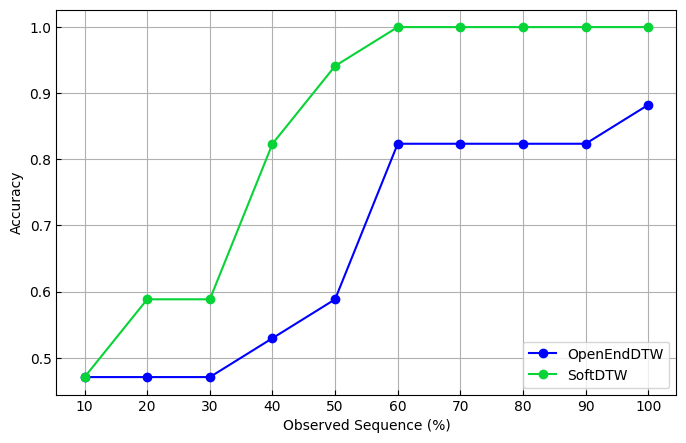

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
config = {'OpenEndDTW': {'acc': [results_all['OpenEndDTW']['coords'][r]['acc'] for r in OBS_RATIOS],
                          'color': 'blue'}, 
          'SoftDTW': {'acc': [results_all['SoftDTW']['coords'][r]['acc'] for r in OBS_RATIOS],
                     'color': '#08D337'}}

for label, res in config.items():
    plt.plot(OBS_RATIOS, res['acc'], marker='o', label=label, color=res['color'])

plt.xlabel("Observed Sequence (%)")
plt.ylabel("Accuracy")
#plt.title("OpenEnd-DTW")
plt.grid()
plt.legend(loc='lower right')
plt.xticks(OBS_RATIOS)
#plt.ylim(0.2, 1)

plt.tick_params(axis='both', direction='in', which='both')
plt.show()

### Soft-DTW

In [10]:

###########################
# same results as tslearn #
###########################

import sys
sys.path.append('../../pytorch-softdtw-cuda')
from soft_dtw_cuda import SoftDTW
import torch
import numpy as np

from torch import nn

results = {r: {"y_true": [], "y_pred": [], "conf": []} for r in OBS_RATIOS}

# Initialize Soft-DTW (use CPU to avoid CUDA issues)
sdtw = SoftDTW(use_cuda=False, gamma=0.1)
    
for r in OBS_RATIOS: 
    soft_dtw_loss = SoftDTWLossPyTorch(gamma=0.1)
    for X_train_i, y_train_i in zip(X_train, y_train_enc):
        T = X_train_i.shape[0]            
        t_obs = max(1, int(np.round(T * r / 100.0)))
        xtr = X_train_i[:t_obs].reshape(-1, X_train_i.shape[1]*X_train_i.shape[2])
        reference = torch.FloatTensor(xtr).unsqueeze(0)  # Add batch dimension

        dists = []
        for X_test_i, y_test_i in zip(X_test, y_test_enc):
            xte = X_test_i[:t_obs].reshape(-1, X_test_i.shape[1]*X_test_i.shape[2])
            query = torch.FloatTensor(xte).unsqueeze(0)  # Add batch dimension
            
            with torch.no_grad():  # No gradients needed for inference
                soft_dtw_dist = sdtw(query, reference)
                distance = soft_dtw_dist.item()  # Convert to scalar
            dists.append((distance, y_test_i))

        dists.sort(key=lambda x: x[0])
        pred = dists[0][1]
        # margin = distance to 2nd nearest
        conf = dists[1][0] - dists[0][0] if len(dists) > 1 else 0.0
        results[r]["y_true"].append(y_train_i)
        results[r]["y_pred"].append(pred)
        results[r]["conf"].append(conf)
            
    acc = accuracy(results[r]["y_true"], results[r]["y_pred"])
    results[r]["acc"] = acc
    print(f"{r}% observed: {acc:.3f}")

    data_id = 'coords'
    results_all['SoftDTW'][data_id] = results

10% observed: 0.471
20% observed: 0.588
30% observed: 0.588
40% observed: 0.824
50% observed: 0.941
60% observed: 1.000
70% observed: 1.000
80% observed: 1.000
90% observed: 1.000
100% observed: 1.000
